# 02 — Os dois indicadores e as visualizações

**Grupo 1 · Tema G2 — Anomalia de carga**

O card do G2 pede dois indicadores: **percentual de amostras anômalas por fase** e
**intensidade do desvio**. Ambos derivam de um mesmo escore robusto, definido primeiro.

Este notebook também executa a **conferência de reprodutibilidade** contra os artefatos
do docente e apresenta a análise central do grupo: o contraste entre a variante V1
(modelo do lab como está) e a V2 (com a correção de qualidade do achado 2).

In [1]:
import sys
from pathlib import Path

sys.path.append("..")          # code/ -> g2_lib.py
from g2_lib import *           # noqa: F403

RAIZ = Path("../..").resolve()
AMOSTRA = RAIZ / "code" / "datasets" / "kpm-ue-tp-sample"
DERIVED = RAIZ / "derived"
FIGURES = RAIZ / "figures"
DERIVED.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("raiz do pacote:", RAIZ.name)
print("fonte:", (AMOSTRA / "kpm.sqlite").relative_to(RAIZ))

raiz do pacote: _pr
fonte: code\datasets\kpm-ue-tp-sample\kpm.sqlite


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

CORES = {"baseline": "#3B7E6D", "stress": "#B25128", "recovery": "#6566A6"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "font.size": 10, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

amostras = carregar_amostras(AMOSTRA / "kpm.sqlite")
baseline = amostras[amostras.phase == "baseline"]
print(f"{len(amostras)} amostras · baseline de treino: {len(baseline)}")

100 amostras · baseline de treino: 20


## 1. O escore robusto (MAD)

Reproduz o `ai_policy_pipeline.py` do lab:

```
escala_f     = max( MAD_f × 1,4826 ,  piso_f )
escore_f(x)  = | x_f − mediana_baseline_f | / escala_f

feature anômala  ⇔  escore_f ≥ 3,5
amostra anômala  ⇔  ao menos 2 das 3 features anômalas
```

A constante 1,4826 converte o MAD em estimativa robusta de desvio-padrão sob
normalidade. O piso evita divisão por zero — e aqui ele **sempre** entra em ação
(achado 4 do notebook 01).

Duas variantes do mesmo modelo:

- **V1** — o baseline é usado como está. Idêntico ao `model.json` do docente.
- **V2** — `DRB.RlcSduDelayDl = 0` é tratado como **ausência**, não como medida.

In [3]:
V1 = treinar(baseline, tratar_delay_zero=False)
V2 = treinar(baseline, tratar_delay_zero=True)

comp = pd.DataFrame([
    {"feature": f, "unidade": UNIDADES[f],
     "n_V1": V1["features"][f]["n"], "mediana_V1": V1["features"][f]["median"],
     "escala_V1": round(V1["features"][f]["escala"], 2),
     "n_V2": V2["features"][f]["n"], "mediana_V2": V2["features"][f]["median"],
     "escala_V2": round(V2["features"][f]["escala"], 2)}
    for f in FEATURES])
display(comp)

,feature,unidade,n_V1,mediana_V1,escala_V1,n_V2,mediana_V2,escala_V2
0,DRB.RlcSduDelayDl,us,20,0.00,1.0,9,137.00,69.68
1,DRB.UEThpUl,kbps,20,3.72,1.0,20,3.72,1.00
2,RRU.PrbTotUl,%,20,2.00,1.0,20,2.00,1.00


> Só o atraso muda entre as variantes: descartadas as 11 amostras não reportadas, a
> mediana do baseline sobe de **0 para 137 µs** e a escala de **1,0 para 69,68** — o
> detector deixa de considerar anômalo qualquer atraso não-nulo.

## 2. Conferência de reprodutibilidade

Antes de usar o detector, provamos que ele é **o mesmo** do docente. Se as medianas, os
MADs e os escores baterem, qualquer divergência posterior é deliberada e não um bug
nosso.

In [4]:
print("--- modelo V1 x model.json do docente")
conf_modelo = conferir_com_docente(V1, AMOSTRA)
display(conf_modelo)

print("--- escores da amostra registrada em decision.json")
conf_escores = conferir_escores_docente(V1, AMOSTRA)
display(conf_escores)

assert conf_modelo["confere"].all(), "modelo V1 divergiu do model.json do docente"
assert conf_escores["confere"].all(), "escores divergiram do decision.json do docente"
print("\nOK — V1 reproduz os artefatos do lab feature a feature.")

--- modelo V1 x model.json do docente


,feature,mediana_nossa,mediana_docente,mad_nosso,mad_docente,confere
0,DRB.RlcSduDelayDl,0.00,0.00,0.0,0.0,True
1,DRB.UEThpUl,3.72,3.72,0.0,0.0,True
2,RRU.PrbTotUl,2.00,2.00,0.0,0.0,True


--- escores da amostra registrada em decision.json


,feature,valor,escore_nosso,escore_docente,confere
0,DRB.RlcSduDelayDl,154.88,154.88,154.88,True
1,DRB.UEThpUl,77216.56,77212.84,77212.84,True
2,RRU.PrbTotUl,99.00,97.00,97.00,True



OK — V1 reproduz os artefatos do lab feature a feature.


## 3. KPI 1 — Taxa de Amostras Anômalas (TAA)

```
TAA(fase) = 100 × n_amostras_anômalas(fase) / n_amostras(fase)
```

| | |
|---|---|
| **Unidade** | % de amostras |
| **Granularidade** | por fase, dentro de um `run_id` |
| **Fonte** | `kpm_samples.payload_json` + `kpm_samples.phase` |

Responde diretamente à pergunta do tema. Contrastada entre fases, mede ao mesmo tempo
a **sensibilidade** (stress) e a **taxa de falso alarme** (baseline e recovery).

## 4. KPI 2 — Índice de Severidade de Carga (ISC)

```
ISC(amostra) = média_f [ min( escore_f / 3,5 , 10 ) ]
```

| | |
|---|---|
| **Unidade** | adimensional (múltiplos do limiar) |
| **Granularidade** | por amostra, agregado por fase |
| **Fonte** | escores das 3 features |

Mede a **intensidade** do desvio, não só a contagem. Normalizado pelo limiar:
**ISC = 1,0 significa "exatamente no limiar"**.

**Por que saturar em 10:** sem o teto, o escore de `DRB.UEThpUl` chega a 77 213 porque a
escala degenerou para 1,0 kbps. Uma média sem saturação vira um termômetro só da vazão,
em kbps, disfarçado de índice adimensional. A célula abaixo demonstra o problema.

In [5]:
pior = amostras.loc[amostras["DRB.UEThpUl"].idxmax()]
bruto = escorar(pior[FEATURES].to_dict(), V1)["scores"]
demo = pd.DataFrame([
    {"feature": f, "unidade": UNIDADES[f], "valor": pior[f],
     "escore_bruto": round(bruto[f], 2),
     "multiplos_do_limiar": round(bruto[f] / SCORE_THRESHOLD, 2),
     "apos_saturacao": round(min(bruto[f] / SCORE_THRESHOLD, ISC_CAP), 2)}
    for f in FEATURES])
display(demo)
print(f"media SEM saturacao : {demo['multiplos_do_limiar'].mean():>12,.2f}  <- dominada pela vazao em kbps")
print(f"media COM saturacao : {demo['apos_saturacao'].mean():>12,.2f}  <- ISC, interpretavel")

,feature,unidade,valor,escore_bruto,multiplos_do_limiar,apos_saturacao
0,DRB.RlcSduDelayDl,us,34.0,34.00,9.71,9.71
1,DRB.UEThpUl,kbps,172316.9,172313.18,49232.34,10.00
2,RRU.PrbTotUl,%,21.0,19.00,5.43,5.43


media SEM saturacao :    16,415.83  <- dominada pela vazao em kbps
media COM saturacao :         8.38  <- ISC, interpretavel


## 5. Resultados — V1 contra V2

O contraste entre as duas variantes **é** a análise do grupo: mede o efeito de uma
única decisão de qualidade sobre o comportamento do detector.

In [6]:
esc_v1 = escorar_df(amostras, V1)
esc_v2 = escorar_df(amostras, V2)
kpi_v1, kpi_v2 = kpis_por_fase(esc_v1), kpis_por_fase(esc_v2)

print("=== V1 — modelo do lab, sem correcao de qualidade"); display(kpi_v1)
print("=== V2 — com delay=0 tratado como ausente");         display(kpi_v2)

resumo = pd.DataFrame({
    "n": kpi_v1["n"],
    "TAA_V1_pct": kpi_v1["TAA_pct"], "TAA_V2_pct": kpi_v2["TAA_pct"],
    "ISC_medio_V1": kpi_v1["ISC_medio"], "ISC_medio_V2": kpi_v2["ISC_medio"],
    "flags_delay_V1": kpi_v1["flags.DRB.RlcSduDelayDl"],
    "flags_delay_V2": kpi_v2["flags.DRB.RlcSduDelayDl"],
})
resumo.to_csv(DERIVED / "kpi_por_fase.csv")
print("gravado:", (DERIVED / "kpi_por_fase.csv").relative_to(RAIZ))
display(resumo)

=== V1 — modelo do lab, sem correcao de qualidade


,n,n_anomalas,TAA_pct,ISC_mediana,ISC_medio,ISC_max,flags.DRB.RlcSduDelayDl,flags.DRB.UEThpUl,flags.RRU.PrbTotUl
phase,,,,,,,,,
baseline,20,0,0.0,0.03,1.51,3.40,9,0,0
stress,60,60,100.0,10.00,9.91,10.00,60,60,59
recovery,20,1,5.0,0.03,1.76,8.38,9,1,1


=== V2 — com delay=0 tratado como ausente


,n,n_anomalas,TAA_pct,ISC_mediana,ISC_medio,ISC_max,flags.DRB.RlcSduDelayDl,flags.DRB.UEThpUl,flags.RRU.PrbTotUl
phase,,,,,,,,,
baseline,20,0,0.0,0.0,0.04,0.18,0,0,0
stress,60,59,98.3,6.7,6.61,6.84,0,60,59
recovery,20,1,5.0,0.0,0.33,5.28,2,1,1


gravado: derived\kpi_por_fase.csv


,n,TAA_V1_pct,TAA_V2_pct,ISC_medio_V1,ISC_medio_V2,flags_delay_V1,flags_delay_V2
phase,,,,,,,
baseline,20,0.0,0.0,1.51,0.04,9,0
stress,60,100.0,98.3,9.91,6.61,60,0
recovery,20,5.0,5.0,1.76,0.33,9,2


### Os quatro insights

1. **O detector separa as fases sem ambiguidade.** 0 % contra 98,3 % de TAA e ISC de
   0,04 contra 6,61 — mais de duas ordens de grandeza. A hipótese do lab se confirma:
   as KPMs E2 distinguem calmo de carregado.

2. **A regra "mínimo 2 features" é o que segura o falso alarme.** No baseline V1, nove
   amostras disparam a flag de atraso isoladamente. Nenhuma vira decisão, porque
   exige-se concordância de duas métricas. Sem essa regra, a TAA de baseline saltaria
   de 0 % para 45 %.

3. **A correção de qualidade elimina a causa raiz.** Em V2 os nove flags espúrios
   desaparecem e o ISC médio de baseline cai de 1,51 para 0,04.

4. **Sobram um falso negativo e um falso alarme, ambos com explicação física** — a
   célula seguinte os identifica.

In [7]:
print("--- se a regra fosse 1 feature (V1), a TAA de baseline seria:")
alt = (esc_v1[esc_v1.phase == "baseline"]["n_features_anomalas"] >= 1).mean() * 100
print(f"    {alt:.1f} %  (contra {kpi_v1.loc['baseline','TAA_pct']:.1f} % com a regra de 2 features)\n")

fn = esc_v2[(esc_v2.phase == "stress") & (~esc_v2.anomala)]
fp = esc_v2[(esc_v2.phase == "recovery") & (esc_v2.anomala)]
print("--- falso NEGATIVO (stress nao detectado) — rampa antes do trafego subir")
display(fn[["phase", "sample_index"] + FEATURES + ["isc", "n_features_anomalas"]])
print("--- falso ALARME (recovery detectado) — cauda do iperf drenando")
display(fp[["phase", "sample_index"] + FEATURES + ["isc", "n_features_anomalas"]])

--- se a regra fosse 1 feature (V1), a TAA de baseline seria:
    45.0 %  (contra 0.0 % com a regra de 2 features)

--- falso NEGATIVO (stress nao detectado) — rampa antes do trafego subir


,phase,sample_index,DRB.RlcSduDelayDl,DRB.UEThpUl,RRU.PrbTotUl,isc,n_features_anomalas
20,stress,0,134.79,15.16,2.0,1.092544,1


--- falso ALARME (recovery detectado) — cauda do iperf drenando


,phase,sample_index,DRB.RlcSduDelayDl,DRB.UEThpUl,RRU.PrbTotUl,isc,n_features_anomalas
80,recovery,0,34.0,172316.9,21.0,5.283632,2


## 6. Visualizações

Quatro plots, com unidade nos eixos e um insight por figura. Exportados em `figures/`.

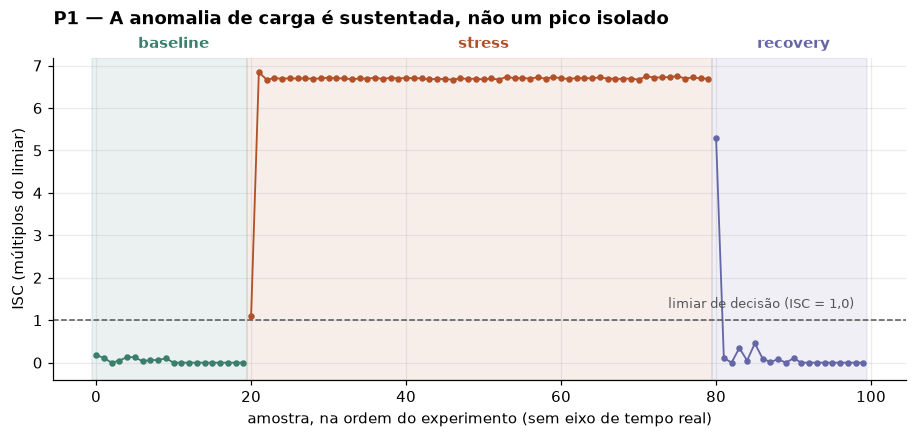

In [8]:
# --- P1: ISC ao longo do experimento, com as fases sombreadas
ordem = esc_v2.reset_index(drop=True).copy()
ordem["pos"] = range(len(ordem))

fig, ax = plt.subplots(figsize=(10, 3.8))
faixas, ini = [], 0
for fase in ORDEM_FASES:
    bloco = ordem[ordem.phase == fase]
    ax.axvspan(ini - 0.5, ini + len(bloco) - 0.5, color=CORES[fase], alpha=0.10)
    ax.plot(bloco["pos"], bloco["isc"], marker="o", ms=3.2, lw=1.2, color=CORES[fase])
    faixas.append((fase, ini + len(bloco) / 2))
    ini += len(bloco)

ax.axhline(1.0, ls="--", lw=1, color="#555")
ax.set_ylim(bottom=-0.4)
# rotulos de fase acima da area de plotagem: x em dados, y em fracao dos eixos
from matplotlib.transforms import blended_transform_factory
tr = blended_transform_factory(ax.transData, ax.transAxes)
for fase, centro in faixas:
    ax.text(centro, 1.02, fase, transform=tr, ha="center", va="bottom",
            color=CORES[fase], fontsize=9.5, fontweight="bold")
ax.annotate("limiar de decisão (ISC = 1,0)", xy=(len(ordem) - 1, 1.0),
            xytext=(-6, 6), textcoords="offset points",
            ha="right", va="bottom", fontsize=8.5, color="#555")
ax.set_xlabel("amostra, na ordem do experimento (sem eixo de tempo real)")
ax.set_ylabel("ISC (múltiplos do limiar)")
ax.set_title("P1 — A anomalia de carga é sustentada, não um pico isolado",
             loc="left", fontweight="bold", pad=22)
plt.savefig(FIGURES / "p1_isc_serie.png"); plt.show()

> **P1.** A fase de stress mantém ISC acima do limiar em 59 das 60 amostras consecutivas: a anomalia é um regime, não um transiente. As fases calmas ficam coladas no zero, com um único pico em recovery.

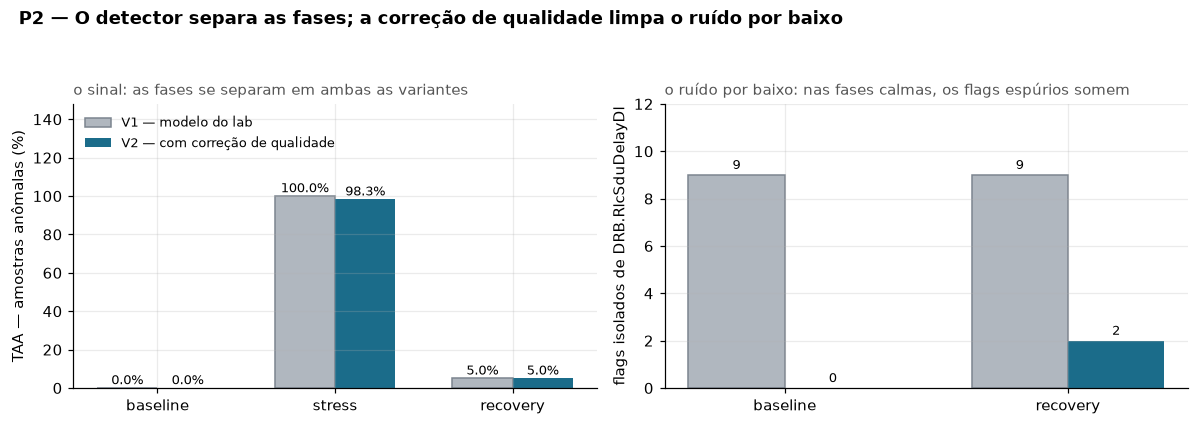

flags isolados de atraso — nao viram decisao (regra de 2 features), mas revelam o ruido:


,V1,V2
phase,,
baseline,9,0
stress,60,0
recovery,9,2


In [9]:
# --- P2: o sinal (TAA) e o ruido por baixo dele (flags de atraso)
import numpy as np
C_V1, C_V2 = "#B0B7BF", "#1B6C8A"
x = np.arange(len(ORDEM_FASES)); larg = 0.34

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.9))

# painel esquerdo — o sinal: TAA nas tres fases
b1 = ax1.bar(x - larg/2, kpi_v1["TAA_pct"], larg, label="V1 — modelo do lab",
             color=C_V1, edgecolor="#7C858F")
b2 = ax1.bar(x + larg/2, kpi_v2["TAA_pct"], larg, label="V2 — com correção de qualidade",
             color=C_V2)
for b in list(b1) + list(b2):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 2, f"{b.get_height():.1f}%",
             ha="center", fontsize=8.5)
ax1.set_xticks(x); ax1.set_xticklabels(ORDEM_FASES)
ax1.set_ylabel("TAA — amostras anômalas (%)", fontsize=9.5); ax1.set_ylim(0, 148)
ax1.legend(frameon=False, fontsize=8.5, loc="upper left")
ax1.set_title("o sinal: as fases se separam em ambas as variantes",
              fontsize=9.5, color="#555", loc="left")

# painel direito — o ruido, so nas fases calmas (no stress o atraso alto e legitimo)
calmas = ["baseline", "recovery"]
xc = np.arange(len(calmas))
c1 = ax2.bar(xc - larg/2, kpi_v1.loc[calmas, "flags.DRB.RlcSduDelayDl"], larg,
             color=C_V1, edgecolor="#7C858F")
c2 = ax2.bar(xc + larg/2, kpi_v2.loc[calmas, "flags.DRB.RlcSduDelayDl"], larg, color=C_V2)
for b in list(c1) + list(c2):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.25, f"{b.get_height():.0f}",
             ha="center", fontsize=8.5)
ax2.set_xticks(xc); ax2.set_xticklabels(calmas)
ax2.set_ylabel("flags isolados de DRB.RlcSduDelayDl", fontsize=9.5); ax2.set_ylim(0, 12)
ax2.set_title("o ruído por baixo: nas fases calmas, os flags espúrios somem",
              fontsize=9.5, color="#555", loc="left")

fig.suptitle("P2 — O detector separa as fases; a correção de qualidade limpa o ruído por baixo",
             x=0.02, ha="left", fontweight="bold", fontsize=11.5)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.savefig(FIGURES / "p2_taa_por_fase.png"); plt.show()

print("flags isolados de atraso — nao viram decisao (regra de 2 features), mas revelam o ruido:")
display(pd.DataFrame({"V1": kpi_v1["flags.DRB.RlcSduDelayDl"],
                      "V2": kpi_v2["flags.DRB.RlcSduDelayDl"]}))

> **P2.** A TAA salta de 0 % para ~98 % entre baseline e stress em ambas as variantes — o
> sinal é robusto e não depende da nossa correção. O que a correção muda é o ruído por
> baixo: os nove flags espúrios de atraso em cada fase calma desaparecem.
>
> **Observação honesta sobre o stress.** Em V2 o atraso também deixa de disparar durante o
> stress (de 60 flags para 0): com a mediana de baseline em 137 µs e escala 69,68, os
> ~159 µs da fase de carga ficam a menos de meio desvio. Isso é perda de sensibilidade
> naquela feature — mas **não muda a decisão**, porque vazão e PRB já bastam para a regra
> de duas features. A conclusão prática é que, neste lab, **o atraso RLC não é um bom
> discriminador de carga**; quem separa as fases é PRB e vazão.

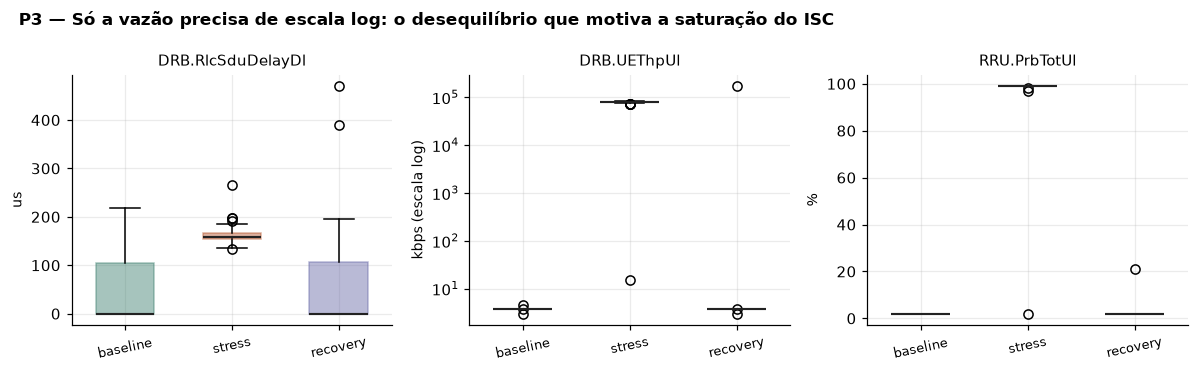

In [10]:
# --- P3: distribuicao das tres metricas por fase
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, f in zip(axes, FEATURES):
    dados = [amostras[amostras.phase == p][f].dropna() for p in ORDEM_FASES]
    bp = ax.boxplot(dados, patch_artist=True, widths=0.55,
                    medianprops={"color": "#222", "lw": 1.4})
    for caixa, fase in zip(bp["boxes"], ORDEM_FASES):
        caixa.set(facecolor=CORES[fase], alpha=0.45, edgecolor=CORES[fase])
    ax.set_xticklabels(ORDEM_FASES, fontsize=8.5, rotation=12)
    ax.set_title(f, fontsize=9.5)
    ax.set_ylabel(UNIDADES[f], fontsize=9)
    if f == "DRB.UEThpUl":
        ax.set_yscale("symlog"); ax.set_ylabel("kbps (escala log)", fontsize=9)
fig.suptitle("P3 — Só a vazão precisa de escala log: o desequilíbrio que motiva a saturação do ISC",
             x=0.02, ha="left", fontweight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(FIGURES / "p3_distribuicoes.png"); plt.show()

> **P3.** A vazão UL varia quatro ordens de grandeza entre fases e precisa de escala logarítmica; PRB e atraso cabem em escala linear. É esse desequilíbrio de unidades que torna a média de escores brutos inútil sem saturação.

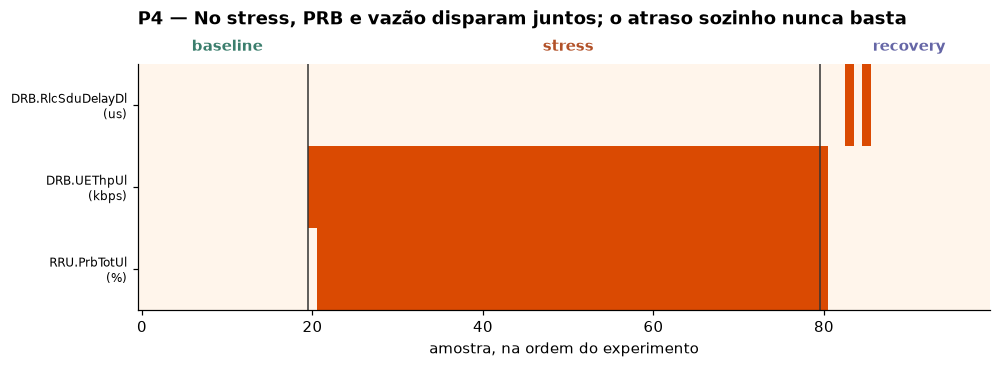

figuras gravadas em figures
  - p1_isc_serie.png
  - p2_taa_por_fase.png
  - p3_distribuicoes.png
  - p4_matriz_features.png


In [11]:
# --- P4: quais features disparam, amostra a amostra
mat = ordem[[f"anomala.{f}" for f in FEATURES]].to_numpy(dtype=float).T
fig, ax = plt.subplots(figsize=(10, 2.9))
ax.imshow(mat, aspect="auto", cmap="Oranges", vmin=0, vmax=1.35, interpolation="nearest")
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([f"{f}\n({UNIDADES[f]})" for f in FEATURES], fontsize=8)
ax.grid(False)
tr4 = blended_transform_factory(ax.transData, ax.transAxes)
ini = 0
for fase in ORDEM_FASES:
    n = int((ordem.phase == fase).sum())
    if ini:
        ax.axvline(ini - 0.5, color="#333", lw=1)
    ax.text(ini + n/2, 1.04, fase, transform=tr4, ha="center", va="bottom",
            color=CORES[fase], fontsize=9.5, fontweight="bold")
    ini += n
ax.set_xlabel("amostra, na ordem do experimento")
ax.set_title("P4 — No stress, PRB e vazão disparam juntos; o atraso sozinho nunca basta",
             loc="left", fontweight="bold", pad=26)
plt.savefig(FIGURES / "p4_matriz_features.png"); plt.show()

print("figuras gravadas em", FIGURES.relative_to(RAIZ))
for p in sorted(FIGURES.glob("*.png")):
    print("  -", p.name)

> **P4.** A concordância exigida pela regra de duas features aparece visualmente: no stress, as faixas de vazão e PRB estão preenchidas em bloco. Nas fases calmas as marcas são esparsas e isoladas — exatamente o que a regra descarta.

## O que os indicadores **não** provam

- A **TAA não mede duração em segundos** — não há timestamp por amostra (achado 1).
  Mede fração de amostras, e amostras não são equiespaçadas por construção.
- O **ISC não é probabilidade** nem grau de confiança. É distância ao baseline em
  múltiplos do limiar, saturada — comparável entre fases do mesmo run, não entre runs.
- Nenhum dos dois **prova causa**. Dizem que a rede saiu do normal, não por quê.
- As fases são rótulo **de construção do experimento**, não verdade de campo
  independente: verificamos concordância com o roteiro, não validamos contra a realidade.

**Próximo:** `03_decisao_a1.ipynb` — da detecção à decisão e à política A1 em dry-run.